In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

In [99]:
from gold_price_ds.dataset import load_raw_data

data = load_raw_data()

print(data.columns)

Index(['adj close', 'close', 'high', 'low', 'open', 'volume', 'ma_7', 'ma_30',
       'ma_90', 'daily_return', 'volatility_7', 'volatility_30', 'rsi', 'macd',
       'macd_signal', 'bb_upper', 'bb_lower'],
      dtype='str')


In [100]:
#Checking Correlation
corrs = data.corr()["close"].sort_values(ascending = False)
print("Correlation Values for the Raw Features")
print(corrs)

Correlation Values for the Raw Features
adj close        1.000000
close            1.000000
low              0.999801
high             0.999363
open             0.999166
ma_7             0.998617
bb_upper         0.997097
ma_30            0.995413
bb_lower         0.992017
ma_90            0.990971
macd_signal      0.754762
macd             0.738666
volatility_30    0.526533
rsi              0.429070
volatility_7     0.376799
daily_return     0.096007
volume           0.013694
Name: close, dtype: float64


In [101]:
#Feature Selection and Feature Engineering
data["price_to_ma7"] = data['close']/data['ma_7']
data['price_to_ma30'] = data['close']/data['ma_30']
data['macd_histogram'] = data['macd'] - data['macd_signal']
data['bb_width'] = (data['bb_upper'] - data['bb_lower']) / data['ma_30']
data['log_return'] = np.log(data['close'] /  data['close'].shift(1))
data["volume_zscore"] = (data['volume'] - data['volume'].rolling(window=20).mean()) / data["volume"].rolling(window=20).std()
data['target'] = (data['log_return'].shift(-1) > 0).astype(int)
data["rsi_diff"] = data['rsi'].diff()
data['volume_zscore_lag'] = data['volume_zscore'].shift(1)
data.dropna(inplace=True)
selected_features = ['log_return', 'price_to_ma7', 'price_to_ma30', 'macd_histogram', 'rsi', 'volume_zscore', 'bb_width', 'target', 'rsi_diff', 'volume_zscore_lag']

data = data[selected_features]



In [102]:
print("Skewness report to the selected features")
print(data.skew())


Skewness report to the selected features
log_return          -1.455385
price_to_ma7         0.199170
price_to_ma30        0.662389
macd_histogram       0.626796
rsi                  0.046671
volume_zscore        2.902161
bb_width             1.528461
target              -0.212447
rsi_diff            -1.006695
volume_zscore_lag    2.905410
dtype: float64


In [105]:
#Building a Baseline Random Forest Classfier Model
tscv = TimeSeriesSplit(n_splits=5)

X = data.drop(columns=['target'])
y = data['target']

rfc_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rfc", RandomForestClassifier(n_estimators=500, max_depth=5, class_weight='balanced', random_state=10))
])

for train_index, test_index in tscv.split(X):
    x_train, x_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    rfc_pipeline.fit(x_train, y_train)
    rfc_predictions = rfc_pipeline.predict(x_test)

    #Metric Checks
    print("Baseline Model Classification Report")
    print(classification_report(y_test, rfc_predictions))


Baseline Model Classification Report
              precision    recall  f1-score   support

           0       0.53      0.27      0.36        95
           1       0.51      0.76      0.61        96

    accuracy                           0.52       191
   macro avg       0.52      0.52      0.49       191
weighted avg       0.52      0.52      0.49       191

Baseline Model Classification Report
              precision    recall  f1-score   support

           0       0.46      0.42      0.44        96
           1       0.46      0.51      0.48        95

    accuracy                           0.46       191
   macro avg       0.46      0.46      0.46       191
weighted avg       0.46      0.46      0.46       191

Baseline Model Classification Report
              precision    recall  f1-score   support

           0       0.46      0.66      0.54        85
           1       0.59      0.39      0.47       106

    accuracy                           0.51       191
   macro avg     

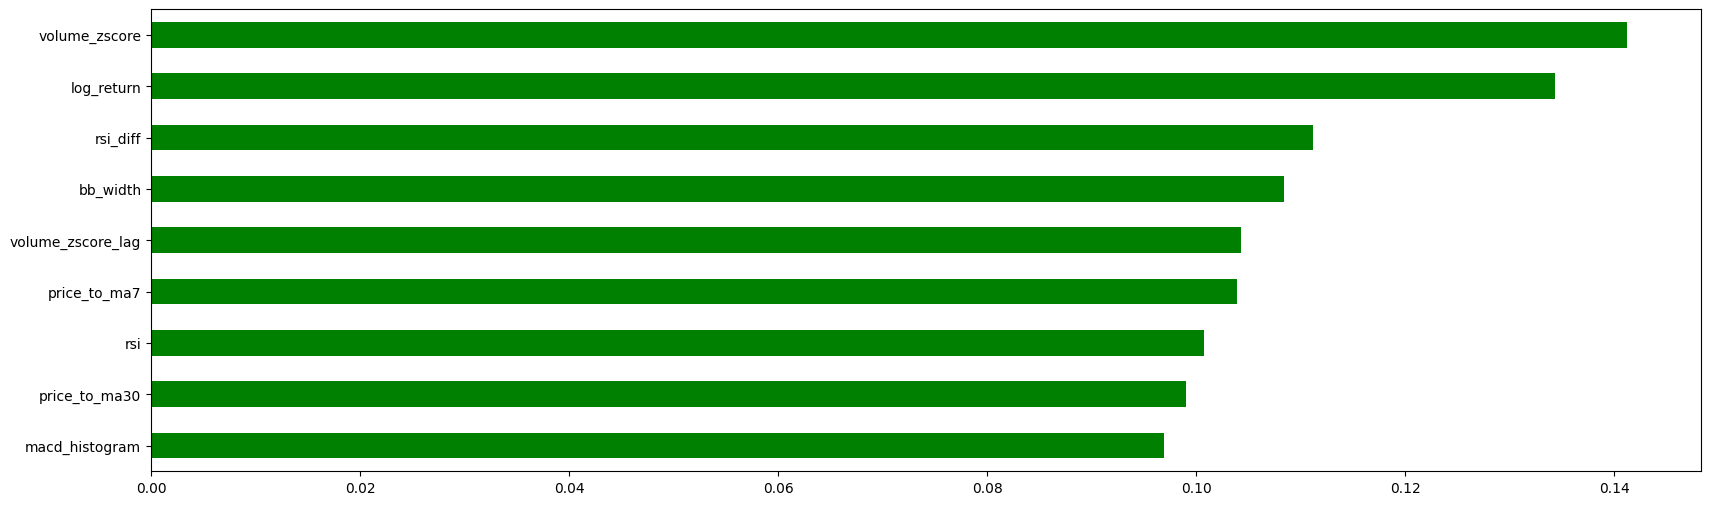

In [104]:
#Checking Feature Importance
importances = rfc_pipeline.named_steps['rfc'].feature_importances_

feat_importances = pd.Series(importances, index=X.columns)
plt.figure(figsize=(20, 6))
feat_importances.sort_values().plot(kind='barh', color='green')
plt.show()